---
title: Bayesian HMM GLM
subtitle: Poisson HMM with Covariate-Dependent Emissions
description: Hidden Markov Model with Poisson emissions. Priors and covariates on initial probabilities and transition matrix. On emission is set up a GLM.
format: html
jupyter: python3
editor_options:
       chunk_output_type: inline
author: ["Erik De Luca","Tommaso Piscitelli"]
categories: ["Pyro", "Python", "HMM", "Bayesian Models", "Viterbi Algorithm", "GLM"]
date: 2025-07-30
---



# Import and clean data
Import functions and data into the notebook. 
The data is located in the *data* folder, while the functions are in the *python* folder. 
To enhance the readability of the notebook and reduce code redundancy, certain functions are organized into python files and imported as needed.

In [11]:
from pyprojroot import here
import sys

python_dir = str(here("python"))
if python_dir not in sys.path:
    sys.path.insert(0, python_dir)

%load_ext autoreload
%autoreload 2

The autoreload extension is already loaded. To reload it, use:
  %reload_ext autoreload


In [12]:
# data manipulation
import pandas as pd
import numpy as np
import polars as pl
import torch

# models
from hmmlearn import hmm
from pyprojroot import here
import pyro
import pyro.distributions as dist
import pyro.distributions.constraints as constraints
from pyro.infer import SVI, TraceEnum_ELBO, config_enumerate
from pyro.optim import Adam
from scipy.stats import poisson

# data visualization
import matplotlib.pyplot as plt
from matplotlib import font_manager
import seaborn as sns
# plot settings
from matplotlib import font_manager as fm
from cycler import cycler
plt.rcParams["axes.prop_cycle"] = cycler(color=["#8c1c13ff", "#86ba90ff", "#54403bff"])
plt.rcParams['figure.facecolor'] = "#eee3d3"
fm.fontManager.addfont(here("python/Figtree-Regular.ttf"))
state_cols = ["#8c1c13ff", "#df9457ff", "#86ba90ff", "#54403bff"]

data = pd.read_csv(here("data/recent_donations.csv"))
data

,unique_number,class_year,birth_year,first_donation_year,gender,y_2009,y_2010,y_2011,y_2012,y_2013,y_2014,y_2015,y_2016,y_2018,y_2019,y_2017,y_2020,y_2021,y_2022,y_2023
0,26308560,"(1960,1970]",1965,1985,M,0,0,0,0,0,0,0,0,0,0,0,1,1,3,1
1,26309283,"(1960,1970]",1966,2002,M,2,1,2,2,1,1,3,3,4,1,3,3,3,3,4
2,26317365,"(1960,1970]",1961,1984,M,4,2,3,3,3,4,3,3,2,3,3,2,0,1,0
3,26318451,"(1960,1970]",1967,1989,M,0,3,3,4,4,4,2,3,3,1,2,3,1,0,0
4,26319465,"(1960,1970]",1964,1994,F,1,2,2,1,2,1,1,0,0,2,1,1,1,1,1
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
9231,27220599,"(1970,1980]",1980,2022,M,0,0,0,0,0,0,0,0,0,0,0,0,0,2,0
9232,27220806,"(2000,2010]",2002,2022,M,0,0,0,0,0,0,0,0,0,0,0,0,0,2,3
9233,27221247,"(1990,2000]",2000,2022,F,0,0,0,0,0,0,0,0,0,0,0,0,0,2,0
9234,27221274,"(1960,1970]",1966,2022,F,0,0,0,0,0,0,0,0,0,0,0,0,0,2,3


The data is pre-processed via *Polars*'s library and transformed into torch elements.

In [13]:
# from pandas to polars
df = pl.from_pandas(data)  # or: df = pl.read_csv("file.csv")

# collect donation numbers along years
year_cols = sorted([c for c in df.columns if c.startswith("y_")])
T = len(year_cols)
obs = (
    df.select(year_cols)
      .fill_null(0)
      .to_numpy()
      .astype(int)  # (N,T)
)

# prepare fixed covariates for pi
df = df.with_columns([
    (pl.col("gender") == "F").cast(pl.Int8).alias("gender_code"),
    ((pl.col("birth_year") - pl.col("birth_year").mean()) /
     pl.col("birth_year").std()).alias("birth_year_norm")
])

birth_year_norm = df["birth_year_norm"].to_numpy()  # (N,)
gender_code     = df["gender_code"].to_numpy()      # (N,)
intercept = np.ones_like(birth_year_norm)

cov_init = np.stack([intercept, birth_year_norm, gender_code], axis=1)  # (N,2)

# dynamic base: ages (N,T) and covid dummy (N,T)
years_num  = np.array([int(c[2:]) for c in year_cols])  # e.g. [2009, …, 2023]
ages       = years_num[None, :] - df["birth_year"].to_numpy()[:, None]  # (N,T)

covid_mask  = np.isin(years_num, [2020, 2021, 2022]).astype(float)  # (T,)
covid_years = np.tile(covid_mask, (df.height, 1))                   # (N,T)

# age bins over the FULL df (N,T) -> one-hot (N,T,7)
# bins: [0,25), [25,35), [35,45), [45,55), [55,65), [65,75), [75,120]
age_bins = np.array([18, 25, 35, 45, 55, 60, 65, 75])
ages_binned = np.digitize(ages, age_bins, right=False)   # 1..7
n_agebins = len(age_bins) - 1
ages_binned = np.clip(ages_binned, 1, n_agebins)

ages_onehot = np.eye(n_agebins)[ages_binned - 1][:, :, 1:] # drop the baseline 18-24

intercept_tile = np.ones((ages_onehot.shape[0], ages_onehot.shape[1], 1))  

cov_tran = np.concatenate([
    intercept_tile,
    ages_onehot,                       # (N,T,6)
    covid_years[:, :, None]            # (N,T,1) -> expand with none
], axis=2)

# emission covariates (N,T,9): gender + 7 age-bin dummies + covid
gender_code_tile = np.repeat(gender_code[:, None], T, axis=1)       # (N,T)
cov_emission = np.concatenate([
    intercept_tile,
    gender_code_tile[:, :, None],     # (N,T,1)
    ages_onehot,                      # (N,T,7)
    covid_years[:, :, None],          # (N,T,1)
], axis=2)                            # (N,T,9)

# to torch
obs_torch       = torch.tensor(obs,          dtype=torch.long)   # (N,T)
cov_init_torch  = torch.tensor(cov_init,     dtype=torch.float)  # (N,2)
cov_tran_torch  = torch.tensor(cov_tran,     dtype=torch.float)  # (N,T,8)
cov_emiss_torch = torch.tensor(cov_emission, dtype=torch.float)  # (N,T,9)

print("obs        :", obs_torch.shape)
print("pi covs    :", cov_init_torch.shape)
print("A covs     :", cov_tran_torch.shape)
print("emission   :", cov_emiss_torch.shape)

obs        : torch.Size([9236, 15])
pi covs    : torch.Size([9236, 3])
A covs     : torch.Size([9236, 15, 8])
emission   : torch.Size([9236, 15, 9])


We are planning to create two models:

- **Development Model**: This model will be used for development purposes, where we will split the observations into training and testing sets. We will evaluate the model's bias and variance to ensure its reliability and performance.

- **Production Model**: This model will be integrated into the dashboard, with the primary goal of achieving the best possible predictions. In this case, more data will enhance the model's predictive power and accuracy. So, we will use the full dataset to train it.

In [14]:
# stratified split 90/10 by gender × age-bin (age at t=0)
N, T = obs_torch.shape
age0 = ages[:, 0]                                          # (N,)
age0_bin = np.digitize(age0, age_bins, right=False)        # 1..7
age0_bin = np.clip(age0_bin, 1, n_agebins)
labels = np.array([f"{int(g)}-{int(b)}" for g, b in zip(gender_code, age0_bin)])

rng = np.random.default_rng(42)
indices = np.arange(N)
test_idx = []
for lab in np.unique(labels):
    idx_lab = indices[labels == lab]
    if idx_lab.size == 0:
        continue
    n_test = max(1, int(np.ceil(0.10 * idx_lab.size)))
    pick = rng.choice(idx_lab, size=n_test, replace=False)
    test_idx.append(pick)

test_idx = np.sort(np.concatenate(test_idx))
train_idx = np.setdiff1d(indices, test_idx)

# subset train and test
obs_train = obs_torch[train_idx]
xpi_train = cov_init_torch[train_idx]
xA_train  = cov_tran_torch[train_idx]
cov_train = torch.cat([xpi_train, xA_train[:, -1, :]], dim=1)  # (2 + 8) cols

obs_test = obs_torch[test_idx]
xpi_test = cov_init_torch[test_idx]
xA_test  = cov_tran_torch[test_idx]
cov_test = torch.cat([xpi_test, xA_test[:, -1, :]], dim=1)

cov_emission_train = cov_emiss_torch[train_idx]  # (N_train, T, 9)
cov_emission_test  = cov_emiss_torch[test_idx]   # (N_test,  T, 9)

print(f"N train = {obs_train.shape[0]}, N test = {obs_test.shape[0]}")
print("emission (train):", cov_emission_train.shape)
print("emission (test) :", cov_emission_test.shape)

N train = 8308, N test = 928
emission (train): torch.Size([8308, 15, 9])
emission (test) : torch.Size([928, 15, 9])


Covariates names, useful for labeling the plots

In [15]:
import hmm_glm_plots as hmm_pl

# age_bins = np.array([0, 25, 35, 45, 55, 65, 75, 120])
age_years_levels = ["18-24","25-34","35-44","45-54","55-59","60-64", "+65"] # TODO: #2 improve age bins  
ref_age_level = "18-24"

cov_names_pi = [
    "intercept",
    "birth_year_norm",
    "gender_code"
]


age_fac_cols = hmm_pl.expand_factor_names("age_years", age_years_levels, ref_level=ref_age_level)
cov_names_A = ["intercept"] + age_fac_cols + ["covid_years"]

em_age_fac_cols = hmm_pl.expand_factor_names("age_years", age_years_levels, ref_level=ref_age_level)
cov_names_em = ["intercept", "gender"] + em_age_fac_cols + ["covid_years"]



# Model

Let $x^\pi_n \in \mathbb{R}^2$ encode (`birth_year_norm`, `gender_code`), $x^A_{n,t} \in \mathbb{R}^8$ encode transition covariates (seven age-bin dummies and a covid indicator), and $x^{em}_{n,t} \in \mathbb{R}^9$ encode emission covariates (gender, seven age-bin dummies, covid).

- Hidden state $z_{n,t} \in \{0,1,2\}$
- Observed count $y_{n,t} \in \mathbb{N}$

**Priors**
Asymmetric priors are set up to ensure divisibility from on state to other.
- $\pi_{\text{base}} \sim \mathrm{Dirichlet}(\boldsymbol{\alpha}_\pi)$
- $A_{\text{base}}[k,\cdot] \sim \mathrm{Dirichlet}(\boldsymbol{\alpha}_{A_k})$

**Slope parameters to learn**
- $W_\pi \in \mathbb{R}^{K\times 2}$
- $W_A \in \mathbb{R}^{K\times K \times 8}$
- $\beta_{em} \in \mathbb{R}^{K \times (1+9)}$ (intercept plus 9 slopes for emission GLMs)

**Initial-state distribution**
$$
\Pr(z_{n,0}=k \mid x^\pi_n) =
\mathrm{softmax}_k \big( \log \pi_{\text{base},k} + W_{\pi,k} \cdot x^\pi_n \big)
$$

**Transition distribution**
$$
\Pr(z_{n,t}=j \mid z_{n,t-1}=k, \ x^A_{n,t}) =
\mathrm{softmax}_j \big( \log A_{\text{base},kj} + W_{A,kj} \cdot x^A_{n,t} \big)
$$

**Emission (State-specific Poisson GLM with age bins)**
$$
y_{n,t} \mid z_{n,t}=k \sim \mathrm{Poisson}\Big(
  \exp\Big( X^{em}_{n,t} \mathbf{\beta_{em,k}}
  \Big)
\Big)
$$

**Variational guide**
- Point-mass for $\pi_{\text{base}}$ and $A_{\text{base}}$ (Delta).
- All $W_\pi$, $W_A$, $\beta_{em}$ are deterministic Pyro params.

**Training**
- Loss: `TraceEnum_ELBO(max_plate_nesting=1)`
- Optimizer: `Adam(lr = 2e-2)` the value is set up manually to get the optimum ELBO with a fixed iterations

In [30]:
K      = 3      # Number of latent states
C_pi   = cov_init.shape[1]      # Initial-state covariates (birth_year_norm, gender_code)
C_A    = cov_tran.shape[2]      # Transition covariates (ages_norm, covid_years)
C_em   = cov_emission.shape[2]      # Emission covariates (gender, 7 age dummies, covid)

# Asymmetric Dirichlet priors
alpha_pi = torch.tensor([5., 2., 1.])
alpha_A  = torch.tensor([
    [6.,1.,1.],
    [1.,6.,1.],
    [1.,1.,6.]
])

@config_enumerate
def model(obs, x_pi, x_A, x_em):
    N, T = obs.shape

    # 1) Priors/parameters for initial and transition distribution
    pi_base = pyro.sample("pi_base", dist.Dirichlet(alpha_pi))          # [K]
    A_base  = pyro.sample("A_base",  dist.Dirichlet(alpha_A).to_event(1)) # [K, K]
    log_pi_base = pi_base.log()
    log_A_base  = A_base.log()

    # 2) Slope coefficients for initial and transition covariates (learned)
    W_pi = pyro.param("W_pi", torch.zeros(K, C_pi))                  # [K, C_pi]
    W_A  = pyro.param("W_A", torch.zeros(K, K, C_A))                 # [K, K, C_A]

    # 3) State-specific GLM emission coefficients (learned)
    beta_em = pyro.param("beta_em", torch.zeros(K, C_em))        # [K, C_em+1] (intercept + 9 dummies)

    with pyro.plate("seqs", N):
        # Initial hidden state probabilities: depend on x_pi via W_pi
        logits0 = log_pi_base + (x_pi @ W_pi.T)                      # [N, K]
        z_prev = pyro.sample("z_0",
                             dist.Categorical(logits=logits0),
                             infer={"enumerate": "parallel"})

        # Emission at t=0: state-specific GLM on covariates x_em[:, 0, :]
        log_mu0 = (x_em[:, 0, :] * beta_em[z_prev, :]).sum(-1)
        pyro.sample("y_0", dist.Poisson(log_mu0.exp()), obs=obs[:, 0])

        # For t = 1 ... T-1, update state and emit
        for t in range(1, T):
            x_t = x_A[:, t, :]                                      # [N, C_A]
            logitsT = (log_A_base[z_prev] + (W_A[z_prev] * x_t[:, None, :]).sum(-1))     # [N, K]
            z_t = pyro.sample(f"z_{t}",
                             dist.Categorical(logits=logitsT),
                             infer={"enumerate": "parallel"})

            # Emission: state-specific GLM at time t
            log_mu_t = (x_em[:, t, :] * beta_em[z_t, :]).sum(-1)
            pyro.sample(f"y_{t}", dist.Poisson(log_mu_t.exp()), obs=obs[:, t])
            z_prev = z_t

#  GUIDE: Point-mass for pi_base and A_base, params for all slopes
def guide(obs, x_pi, x_A, x_em):
    pi_q = pyro.param(
        "pi_base_map",
        torch.tensor([0.6, 0.3, 0.1]),
        constraint=dist.constraints.simplex
    )

    # Each row: simplex for state-to-state transitions
    A_init = torch.eye(K) * (K - 1.) + 1.
    A_init = A_init / A_init.sum(-1, keepdim=True)
    A_q = pyro.param(
        "A_base_map",
        A_init,
        constraint=dist.constraints.simplex
    )

    pyro.sample("pi_base", dist.Delta(pi_q).to_event(1))
    pyro.sample("A_base",  dist.Delta(A_q).to_event(2))

#  TRAINING: it was run only first time and the saved into models folder
# pyro.clear_param_store()
# svi = SVI(model, guide,
#           Adam({"lr": 2e-2}),
#           loss=TraceEnum_ELBO(max_plate_nesting=1))

# for step in range(1000):
#     loss = svi.step(obs_torch, cov_init_torch, cov_tran_torch, cov_emiss_torch)
#     if step % 100 == 0:
#         print(f"{step:4d}  ELBO = {loss:,.0f}")

# param_path = here("models/hmm_glm_full.pt")
# pyro.get_param_store().save(param_path)
# print(f"ParamStore saved in: {param_path}")

To improve the notebook exectution we fit the model only the first time and then loaded

In [17]:
import hmm_glm_model as hmm_glm

# load the parameters
W_pi, W_A, pi_base, A_base, beta_em = hmm_glm.load_hmm_params(here("models/hmm_glm_full.pt"))
# beta_em

In [18]:
# pyro.render_model(model,
#                  model_args=(obs_torch, cov_init_torch, cov_tran_torch, cov_emiss_torch),
#                 #  render_distributions=True,     # mostra le distribuzioni
#                 #  render_params=True
#                  ) 

## Results

- ELBO steadily decreases from ≈184 k to ≈120 k and then plateaus → optimisation has mostly converged.

- Initial-state distribution $\pi$ – State 0 dominates (80 %), followed by state 2 (15 %); state 1 is rare (5 %). Most donors start in state 0.

- Transition matrix $A$ 
    -   Strong self-persistence: $P(0 \rightarrow 0)=0.83$, $P(1 \rightarrow 1)=0.98$, $P(2 \rightarrow 2)=0.94$.    
    -   Cross-state moves are all < 11 %; once a donor is in a state, they tend to stay there.

- Poisson rates 
    - State 0: most of $\beta$ are negatives. The donation number will be low 
    - State 1: the people who belong to state 1 was more propense to donate during the covid, and in th middle ages.
    - State 2: Who donates very frequently and it icreases with the age, but the coid had a bad effect on them

**Interpretation**: the model has discovered three very stable behavioural profiles -non-donors, heavy donors, and light donors- with rare transitions between them.

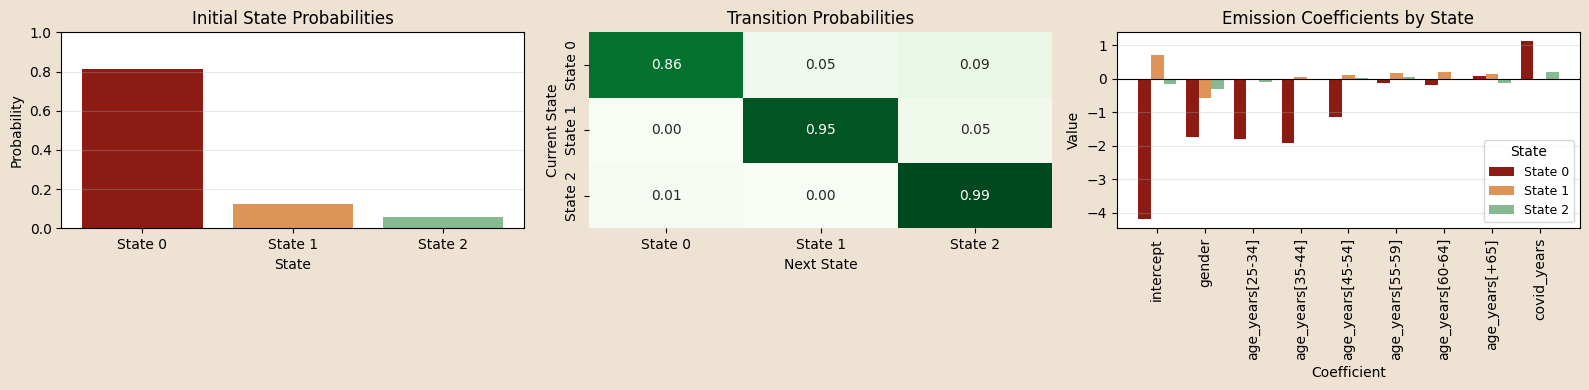

In [19]:
def softmax_row(v):
    e = np.exp(v - np.max(v, axis=-1, keepdims=True))
    return e / e.sum(axis=-1, keepdims=True)

# 2) Covariate means
x_mean_pi = cov_init_torch.mean(dim=0).detach().cpu().numpy()        # (C_pi,)
x_mean_A  = cov_tran_torch.mean(dim=(0, 1)).detach().cpu().numpy()   # (C_A,)

# 3) Mean initial probs and transitions under average covariates
logits_pi = np.log(pi_base + 1e-30) + W_pi @ x_mean_pi
pi_mean   = softmax_row(logits_pi[None, :]).ravel() # ravel flats the dimensions from (1,N) to (N)

K = pi_mean.shape[0]
A_mean = np.zeros((K, K))
for k in range(K):
    logits_row = np.log(A_base[k] + 1e-30) + (W_A[k] @ x_mean_A)
    A_mean[k] = softmax_row(logits_row[None, :]).ravel()

# 4) Names
state_names = [f"State {i}" for i in range(K)]

# Infer emission coefficient names from beta_em shape
C_em = beta_em.shape[1] - 1  # exclude intercept
# coeff_names = [f"feat{i}" for i in range(C_em)] # TODO #5 change coeff_names
include_intercept = True

# Optional check: ensure consistency with covariate tensor
if 'cov_emiss_torch' in globals():
    C_em_from_tensor = int(cov_emiss_torch.shape[-1])
    if C_em_from_tensor != C_em:
        print(f"Warning: beta_em has {C_em} coefficients, but cov_emission tensor has {C_em_from_tensor} features.")

plots = hmm_pl.plot_hmm_params_with_coeffs(
    transitions=A_mean,
    initial_probs=pi_mean,
    beta_em=beta_em,
    state_names=state_names,
    coeff_names=cov_names_em,
)

# Diagnostics


## Viterbi Algorithm (with covariates and Poisson-GLM emissions)

**Goal**: For each donor $n=1..N$, find the MAP latent path $z_{0:T}^\ast$.

**Parameterization (plug-in, posterior means)**
- Covariate-dependent initial distribution:
  - Logits for $\pi$: $\ell_\pi(x_\pi) = \log \pi_{\text{base}} + W_\pi x_\pi$
  - $\pi(x_\pi) = \text{softmax}(\ell_\pi(x_\pi))$
- Covariate-dependent transition matrix:
  - Logits for $A$ at time $t$: $\ell_A(x_{A,t})_{k\to j} = \log A_{\text{base}}[k,j] + \langle W_A[k,j,:], x_{A,t} \rangle$
  - $A(x_{A,t})[k,\cdot] = \text{softmax}_j\bigl(\ell_A(x_{A,t})_{k\to j}\bigr)$
- Emissions:
  - Poisson-GLM per state $k$: $\eta_k(t) = \beta_{em,k,0} + x_{\text{em},t}^T \beta_{em,k}$
  - $\lambda_k(t) = \exp\bigl(\eta_k(t)\bigr)$

**Dynamic Programming**
- Initialization ($t=0$):

$$
\delta_0(k)=\log \pi_k(x_\pi)+\log \text{Poisson}(y_0\mid \lambda_k(0)).
$$

- Recursion for $t=1,\dots,T$:

$$
\delta_t(j)=\max_k\bigl[\delta_{t-1}(k)+\log A_{k\to j}(x_{A,t})\bigr]+\log \text{Poisson}(y_t\mid \lambda_j(t)),
$$

$$
\psi_t(j)=\arg\max_k\bigl[\delta_{t-1}(k)+\log A_{k\to j}(x_{A,t})\bigr].
$$

- Back-tracking:

$$
z_T^\ast=\arg\max_k \delta_T(k),
$$

$$
z_{t-1}^\ast=\psi_t\bigl(z_t^\ast\bigr)\quad\text{for }t=T,\dots,1.
$$


In [20]:
import hmm_glm_viterbi as viterbi

paths = viterbi.viterbi_paths_glm(
    obs_torch,
    cov_init_torch,    # (N,C_pi)
    cov_tran_torch,    # (N,T,C_A)
    cov_emiss_torch,    # (N,T,C_em)
    here("models/hmm_glm_full.pt")
)
switch_rate = (paths[:, 1:] != paths[:, :-1]).any(1).float().mean()
print(f"switch rate = {switch_rate:.2%}")

switch rate = 79.80%


## State occupancy over time (population view)

Looking the plot, it's easy to detect a strong movement from state 0 to state 1 during the covid years. 

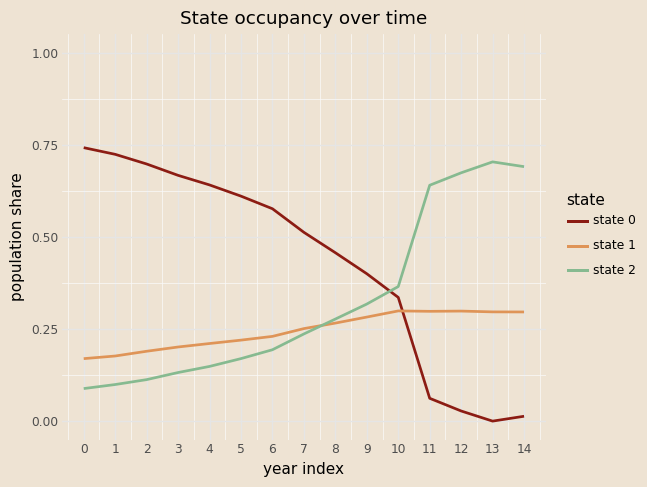

In [21]:
from plotnine import (
    ggplot, aes, geom_line,
    scale_color_manual, scale_x_continuous, scale_y_continuous,
    labs, theme_minimal, theme, element_text
)

# it works for torch and numpy elements
paths_np = paths.detach().cpu().numpy() if hasattr(paths, "detach") else np.asarray(paths)
N, T = paths_np.shape
K = int(paths_np.max()) + 1 if paths_np.size else 1

# Counts per state over time -> (K,T)
counts = np.stack([(paths_np == k).sum(axis=0) for k in range(K)], axis=0)
props = counts / np.maximum(counts.sum(axis=0, keepdims=True), 1)  # avoid div-by-zero

rows = []
for k in range(K):
    for t in range(T):
        rows.append({"t": t, "state": f"state {k}", "share": float(props[k, t])})
df = pd.DataFrame(rows)

(ggplot(df, aes("t", "share", color="state"))
+ geom_line(size=1.1)
+ scale_color_manual(values=state_cols, name="state")
+ scale_x_continuous(breaks=list(range(T)))
+ scale_y_continuous(limits=(0, 1))
+ labs(x="year index", y="population share", title="State occupancy over time")
+ theme_minimal()
+ theme(axis_text_x=element_text(rotation=0)))

## Individual trajectories

Pick a few donors and overlay observations + decoded state for an easy interpretation of the model.

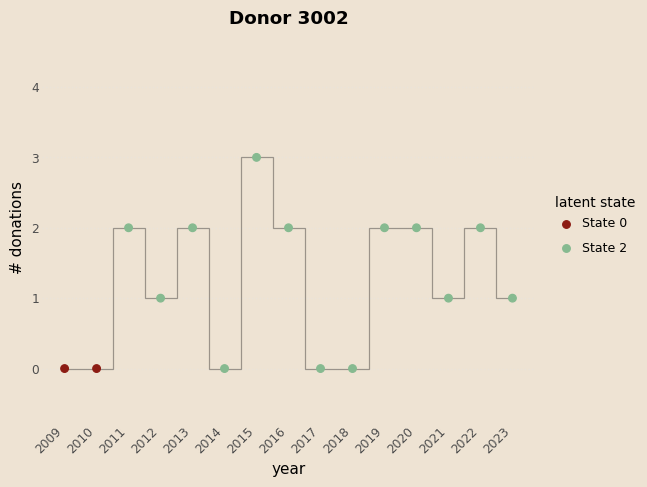

In [22]:

years_axis  = np.arange(2009, 2024)
yticks_vals = np.arange(0, 5)

hmm_pl.plot_one_gg(
        idx=3002,
        obs_torch=obs_torch,
        paths=paths,
        years=years_axis,
        state_cols=None,
        y_max=4
    )

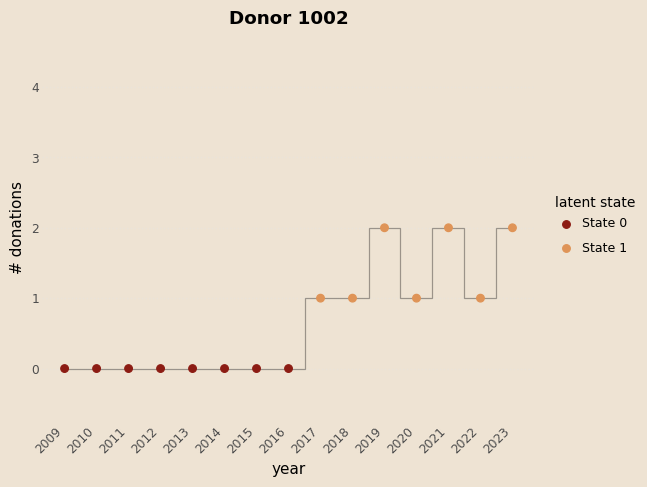

In [23]:
hmm_pl.plot_one_gg(
        idx=1002,
        obs_torch=obs_torch,
        paths=paths,
        years=years_axis,
        state_cols=None,
        y_max=4
    )

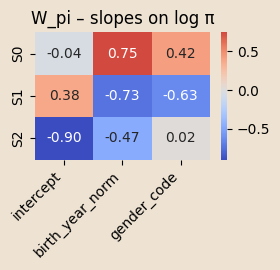

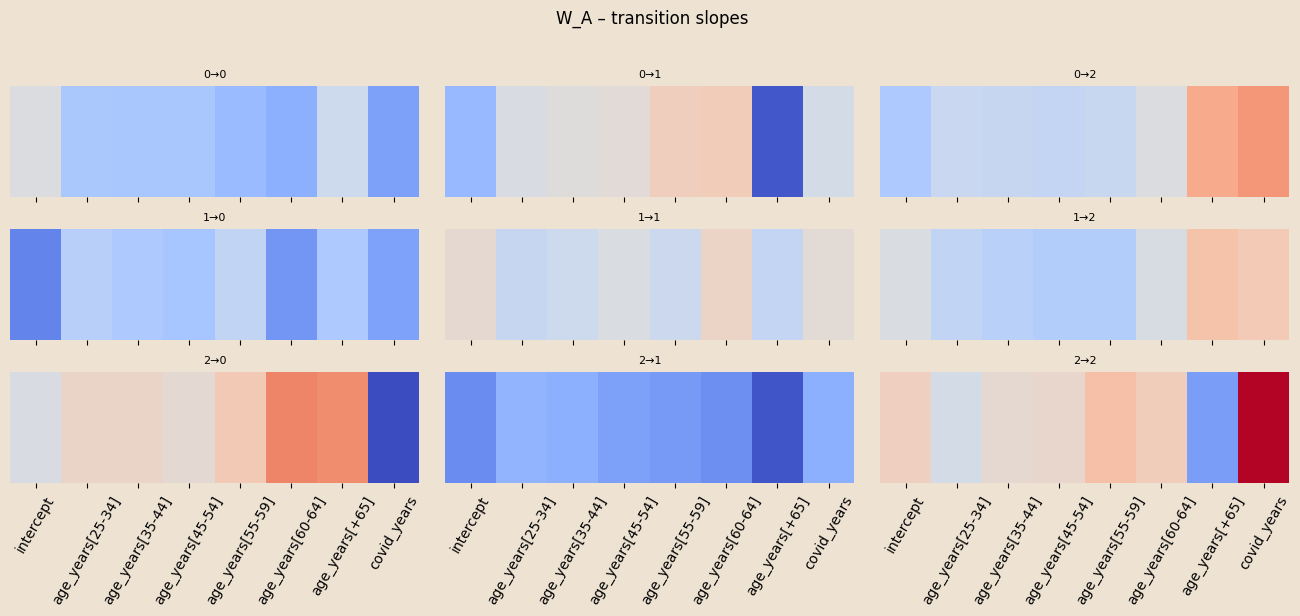

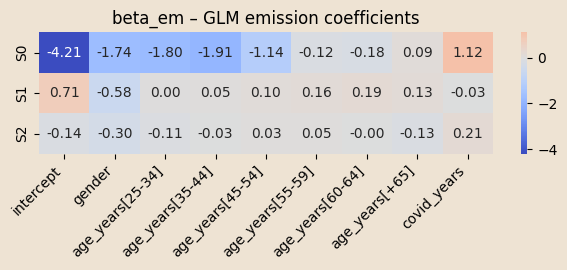

In [24]:
hmm_pl.plot_W_pi_heat(W_pi, cov_names_pi)
hmm_pl.plot_W_A_heat(W_A, cov_names_A)
hmm_pl.plot_beta_em_heat(beta_em, cov_names_em)

## Covariates

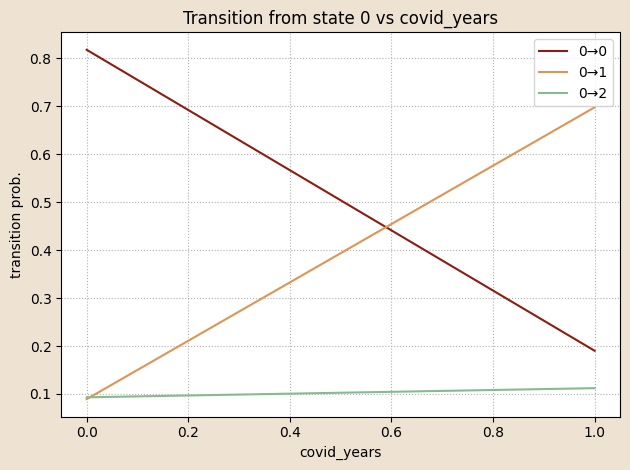

array([[0.81774317, 0.08924908, 0.09300775],
       [0.19011048, 0.69779504, 0.11209447]])

In [25]:
# TODO: #3 Bar chart
# age_bins = np.array([18, 26, 36, 46, 56, 61, 66, 200])  # 7 bands => 7 dummies
# age_bins = bins_split

def age_labels_from_bins(edges: np.ndarray) -> list[str]:
    labels = [f"{a}-{b-1}" for a, b in zip(edges[:-2], edges[1:-1])]
    labels.append(f"{edges[-2]}+")
    return labels

age_levels = age_labels_from_bins(age_bins)  # ["18-25", "26-35", ..., "66+"]


if "ages" not in globals() or "covid_years" not in globals():
    # Requires df and year_cols from your earlier prep
    years_num  = np.array([int(c[2:]) for c in year_cols])            # [2009,...]
    ages       = years_num[None, :] - df["birth_year"].to_numpy()[:, None]  # (N,T)
    covid_mask = np.isin(years_num, [2020, 2021, 2022]).astype(float) # (T,)
    covid_years = np.tile(covid_mask, (ages.shape[0], 1))             # (N,T)


L = len(age_levels)                            # 7
ages_bin = np.digitize(ages, age_bins, right=False) - 1  # 0..6
ages_bin = np.clip(ages_bin, 0, L - 1)
ages_onehot = np.eye(L, dtype=float)[ages_bin]           # (N,T,7)
x_A_data = np.concatenate([ages_onehot, covid_years[..., None]], axis=2)  # (N,T,8)

# 4) Names and factor spec
cov_names_A = [f"age_years[{lab}]" for lab in age_levels] + ["covid_years"]
factor_specs_A = {"age_years": {"levels": age_levels, "ref": None}}  # full one-hot

# 5) Load/prepare model params (W_A, log_A0) as NumPy
try:
    import pyro
    W_A = pyro.param("W_A").detach().cpu().numpy()                   # (K,K,8)
    A_base = pyro.param("A_base_map").detach().cpu().numpy()         # (K,K)
except Exception:
    # Assume already defined in the notebook
    pass
log_A0 = np.log(A_base + 1e-30)

# 6) Sanity check: dimensions must match
assert W_A.shape[2] == x_A_data.shape[2] == len(cov_names_A) == 8, \
    f"Mismatch: W_A C_A={W_A.shape[2]}, x_A_data C_A={x_A_data.shape[2]}, names={len(cov_names_A)}"



#    - Binary plot for covid_years
hmm_pl.plot_trans_vs_cov_orig(
    var="covid_years",
    prev_state=0,
    cov_names_A=cov_names_A,
    x_A_data=x_A_data,
    W_A=W_A,
    log_A0=log_A0,
    grid_orig=np.array([0.0, 1.0])
)

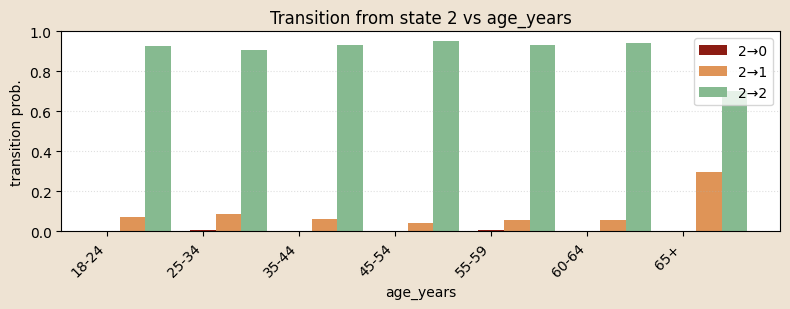

array([[6.22906712e-04, 7.05496142e-02, 9.28827479e-01],
       [6.00650889e-03, 8.58846358e-02, 9.08108855e-01],
       [4.36739425e-03, 6.43864579e-02, 9.31246148e-01],
       [3.00210701e-03, 4.39723634e-02, 9.53025530e-01],
       [6.64406920e-03, 5.93250092e-02, 9.34030922e-01],
       [7.22325789e-04, 5.76753588e-02, 9.41602315e-01],
       [3.99342072e-03, 2.95898419e-01, 7.00108160e-01]])

In [26]:
import hmm_glm_plots as hmm_pl

def build_factor_cols_compat(cov_names, factor_name, levels, ref_level):
    """
    Return:
      - factor_map: dict level -> column index (or None for reference)
      - all_dummy_idx: list of column indices for all non-reference dummies
    Assumes dummy columns are named like: f"{factor_name}[{level}]".
    If ref_level is None, all levels get a dummy column.
    """
    name_to_idx = {n: i for i, n in enumerate(cov_names)}
    factor_map = {}
    all_dummy_idx = []

    for lev in levels:
        col_name = f"{factor_name}[{lev}]"
        if ref_level is not None and lev == ref_level:
            # reference: no column
            factor_map[lev] = None
        else:
            if col_name not in name_to_idx:
                raise ValueError(f"Missing dummy column '{col_name}' in cov_names for factor '{factor_name}'.")
            idx = name_to_idx[col_name]
            factor_map[lev] = idx
            all_dummy_idx.append(idx)

    return factor_map, all_dummy_idx

# Monkey-patch
hmm_pl.build_factor_cols = build_factor_cols_compat

# Re-run your plot call (same as before)
hmm_pl.plot_trans_vs_cov_orig(
    var="age_years",
    prev_state=2,
    cov_names_A=cov_names_A,
    x_A_data=x_A_data,
    W_A=W_A,
    log_A0=log_A0,
    factor_specs_A=factor_specs_A
)

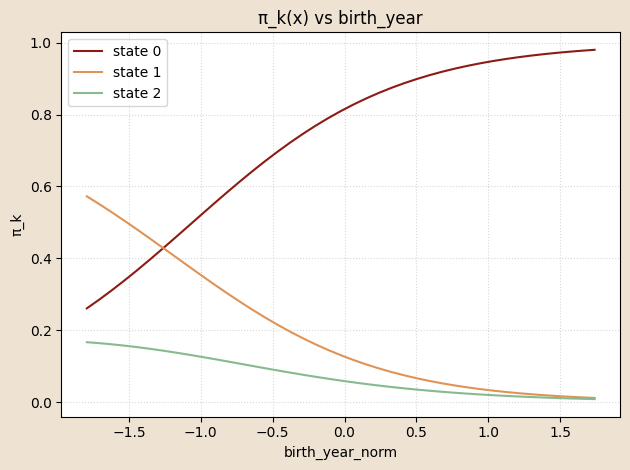

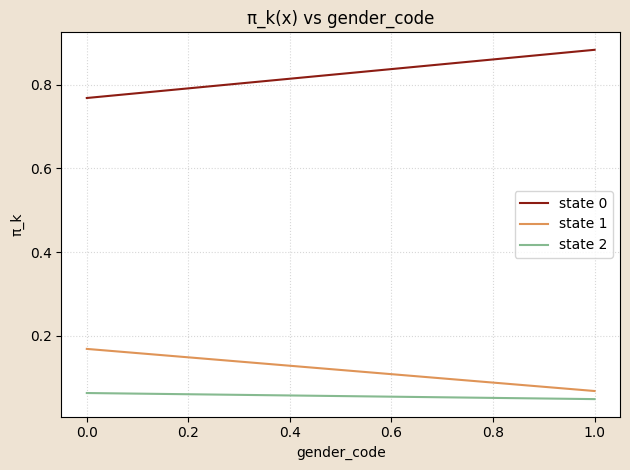

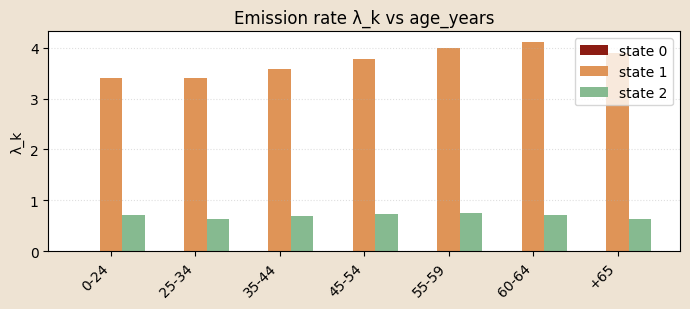

(['0-24', '25-34', '35-44', '45-54', '55-59', '60-64', '+65'],
 array([[1.57045106e-04, 3.40181418e+00, 7.07440388e-01],
        [2.60892494e-05, 3.41246238e+00, 6.36659420e-01],
        [2.31717597e-05, 3.57337913e+00, 6.86505665e-01],
        [5.01270905e-05, 3.77105481e+00, 7.31377490e-01],
        [1.39483187e-04, 3.99872984e+00, 7.42383638e-01],
        [1.31801327e-04, 4.11877744e+00, 7.04907898e-01],
        [1.71178235e-04, 3.89214997e+00, 6.21016135e-01]]))

In [27]:
factor_specs_pi = {}

def levels_from_cov_names(cov_names, factor):
    pref = f"{factor}["
    return [c[c.find("[")+1:-1] for c in cov_names if c.startswith(pref) and c.endswith("]")]
present_levels = levels_from_cov_names(cov_names_em, "age_years")
ref_level = "0-24" if "0-24" not in present_levels else None

age_levels_used = ([ref_level] if ref_level is not None else []) + present_levels

factor_specs_em = {
    "age_years": {
        "levels": age_levels_used,
        "ref": ref_level
    },
    "covid_years": {
        "levels:"
    }
}

# cov_names_A = [f"age_years[{lab}]" for lab in age_levels] + ["covid_years"]

# cov_names_em = ["gender_code"] + [f"age_years[{lab}]" for lab in age_levels] + ["covid_years"]

log_pi0 = np.log(np.clip(pi_base, 1e-30, None))


hmm_pl.plot_pi_vs_cov_orig(
    df=df,
    ages=ages,
    var="birth_year_norm",
    cov_names_pi=cov_names_pi,
    W_pi=W_pi,
    log_pi0=log_pi0,
    x_pi_data=cov_init,
    factor_specs_pi=factor_specs_pi
)

# π_k(x) vs gender_code (binaria)
hmm_pl.plot_pi_vs_cov_orig(
    df=df,
    ages=ages,
    var="gender_code",
    cov_names_pi=cov_names_pi,
    W_pi=W_pi,
    log_pi0=log_pi0,
    x_pi_data=cov_init,
    factor_specs_pi=factor_specs_pi
)

# λ_k(emissione) vs age_years (fattore con 7 livelli)

hmm_pl.plot_lambda_em_vs_cov(
    var_em="age_years",
    beta_em=beta_em,
    cov_names_em=cov_names_em,
    x_em_data=cov_emission,
    factor_specs_em=factor_specs_em    # levels=age_levels, ref=None
)



# Train and test

Let's split the DB into 2 parts, one will be used for the training and the other one for the testing.
After the training of the model the test part will be used to get the probabilities about the donor and its donation the next year. 
Furthermore, we want to analyze the past latent state of the person.

In [28]:
cov_emission_train.shape

torch.Size([8308, 15, 9])

In [31]:
@config_enumerate
def model(obs, x_pi, x_A, x_em):
    N, T = obs.shape

    # 1) Priors/parameters for initial and transition distribution
    pi_base = pyro.sample("pi_base", dist.Dirichlet(alpha_pi))          # [K]
    A_base  = pyro.sample("A_base",  dist.Dirichlet(alpha_A).to_event(1)) # [K, K]
    log_pi_base = pi_base.log()
    log_A_base  = A_base.log()

    # 2) Slope coefficients for initial and transition covariates (learned)
    W_pi = pyro.param("W_pi", torch.zeros(K, C_pi))                  # [K, C_pi]
    W_A  = pyro.param("W_A", torch.zeros(K, K, C_A))                 # [K, K, C_A]

    # 3) State-specific GLM emission coefficients (learned)
    beta_em = pyro.param("beta_em", torch.zeros(K, C_em))        # [K, C_em+1] (intercept + 9 dummies)

    with pyro.plate("seqs", N):
        # Initial hidden state probabilities: depend on x_pi via W_pi
        logits0 = log_pi_base + (x_pi @ W_pi.T)                      # [N, K]
        z_prev = pyro.sample("z_0",
                             dist.Categorical(logits=logits0),
                             infer={"enumerate": "parallel"})

        # Emission at t=0: state-specific GLM on covariates x_em[:, 0, :]
        log_mu0 = (x_em[:, 0, :] * beta_em[z_prev, :]).sum(-1)
        pyro.sample("y_0", dist.Poisson(log_mu0.exp()), obs=obs[:, 0])

        # For t = 1 ... T-1, update state and emit
        for t in range(1, T):
            x_t = x_A[:, t, :]                                      # [N, C_A]
            logitsT = (log_A_base[z_prev] + (W_A[z_prev] * x_t[:, None, :]).sum(-1))     # [N, K]
            z_t = pyro.sample(f"z_{t}",
                             dist.Categorical(logits=logitsT),
                             infer={"enumerate": "parallel"})

            # Emission: state-specific GLM at time t
            log_mu_t = (x_em[:, t, :] * beta_em[z_t, :]).sum(-1)
            pyro.sample(f"y_{t}", dist.Poisson(log_mu_t.exp()), obs=obs[:, t])
            z_prev = z_t

#  GUIDE: Point-mass for pi_base and A_base, params for all slopes
def guide(obs, x_pi, x_A, x_em):
    pi_q = pyro.param(
        "pi_base_map",
        torch.tensor([0.6, 0.3, 0.1]),
        constraint=dist.constraints.simplex
    )

    # Each row: simplex for state-to-state transitions
    A_init = torch.eye(K) * (K - 1.) + 1.
    A_init = A_init / A_init.sum(-1, keepdim=True)
    A_q = pyro.param(
        "A_base_map",
        A_init,
        constraint=dist.constraints.simplex
    )

    pyro.sample("pi_base", dist.Delta(pi_q).to_event(1))
    pyro.sample("A_base",  dist.Delta(A_q).to_event(2))


In [32]:
# pyro.clear_param_store()
# svi = SVI(model, guide, Adam({"lr": 5e-2}), loss=TraceEnum_ELBO(max_plate_nesting=1))

# for step in range(1000):
#     loss = svi.step(obs_train, xpi_train, xA_train, cov_emission_train)
#     if step % 100 == 0:
#         print(f"{step:4d}  ELBO(train) = {loss:,.0f}")

# # # save the model
# pyro.get_param_store().save(here("models/hmm_glm_train.pt"))
# print("Fitted and saved: rates, W_pi, W_A, pi_base_map, A_base_map")

   0  ELBO(train) = 160,214
 100  ELBO(train) = 112,843
 200  ELBO(train) = 112,177
 300  ELBO(train) = 112,032
 400  ELBO(train) = 111,971
 500  ELBO(train) = 111,939
 600  ELBO(train) = 111,919
 700  ELBO(train) = 111,906
 800  ELBO(train) = 111,897
 900  ELBO(train) = 111,891
Fitted and saved: rates, W_pi, W_A, pi_base_map, A_base_map


Load the model and store the parameters

In [ ]:
W_pi, W_A, pi_base, A_base, beta_em = hmm_glm.load_hmm_params(here("models/hmm_glm_train.pt"))

In [ ]:
def log_softmax_logits(logits, dim=-1):
    return logits - torch.logsumexp(logits, dim=dim, keepdim=True)

@torch.no_grad()
def forward_loglik_cov(obs, x_pi, x_A, x_em, model_path="models/hmm_glm_train.pt"):
    device = obs.device
    # ps = pyro.get_param_store()
    # pi_base = ps["pi_base_map"].to(device)
    # A_base  = ps["A_base_map"].to(device)
    # W_pi    = ps["W_pi"].to(device)
    # W_A     = ps["W_A"].to(device)
    # beta_em = ps["beta_em"].to(device)

    W_pi, W_A, pi_base, A_base, beta_em = hmm_glm.load_hmm_params(here(model_path))
    W_pi    = torch.as_tensor(W_pi, device=device, dtype=torch.float32)
    W_A     = torch.as_tensor(W_A, device=device, dtype=torch.float32)
    pi_base = torch.as_tensor(pi_base, device=device, dtype=torch.float32)
    A_base  = torch.as_tensor(A_base, device=device, dtype=torch.float32)
    beta_em = torch.as_tensor(beta_em, device=device, dtype=torch.float32)

    N, T = obs.shape
    K = pi_base.shape[0]
    B  = beta_em[:, :]
    log_mu = torch.einsum("ntc,kc->ntk", x_em.to(device), B)
    emis_log = dist.Poisson(rate=log_mu.exp()).log_prob(obs.unsqueeze(-1))  # (N,T,K)

    log_pi = log_softmax_logits(pi_base.log() + x_pi @ W_pi.T, dim=1)       # (N,K)
    log_alpha = log_pi + emis_log[:, 0]

    log_A0 = A_base.log()
    for t in range(1, T):
        x_t = x_A[:, t, :]
        logits = log_A0.unsqueeze(0) + (W_A.unsqueeze(0) * x_t[:, None, None, :]).sum(-1)
        log_A = log_softmax_logits(logits, dim=2)
        log_alpha = torch.logsumexp(log_alpha.unsqueeze(2) + log_A, dim=1) + emis_log[:, t]
    return torch.logsumexp(log_alpha, dim=1)  # (N,)

@torch.no_grad()
def one_step_ahead_metrics(obs, x_pi, x_A, x_em, model_path="models/hmm_glm_train.pt"):
    import numpy as np
    device = obs.device
    # ps = pyro.get_param_store()
    # pi_base = ps["pi_base_map"].to(device)
    # A_base  = ps["A_base_map"].to(device)
    # W_pi    = ps["W_pi"].to(device)
    # W_A     = ps["W_A"].to(device)
    # beta_em = ps["beta_em"].to(device)

    W_pi, W_A, pi_base, A_base, beta_em = hmm_glm.load_hmm_params(here(model_path))
    W_pi    = torch.as_tensor(W_pi, device=device, dtype=torch.float32)
    W_A     = torch.as_tensor(W_A, device=device, dtype=torch.float32)
    pi_base = torch.as_tensor(pi_base, device=device, dtype=torch.float32)
    A_base  = torch.as_tensor(A_base, device=device, dtype=torch.float32)
    beta_em = torch.as_tensor(beta_em, device=device, dtype=torch.float32)
    
    N, T = obs.shape
    K = pi_base.shape[0]
    B  = beta_em[:, :]
    log_mu = torch.einsum("ntc,kc->ntk", x_em.to(device), B)
    emis_log = dist.Poisson(rate=log_mu.exp()).log_prob(obs.unsqueeze(-1))

    log_pi = log_softmax_logits(pi_base.log() + x_pi @ W_pi.T, dim=1)
    log_alpha = torch.empty(N, T, K, device=device)
    log_alpha[:, 0] = log_pi + emis_log[:, 0]
    alpha_norm = (log_alpha[:, 0] - torch.logsumexp(log_alpha[:, 0], dim=1, keepdim=True)).exp()

    preds_mean, preds_pdon, logscore, y_next_all = [], [], [], []
    log_A0 = A_base.log()

    for t in range(0, T - 1):
        x_t1 = x_A[:, t + 1, :]
        logits = log_A0.unsqueeze(0) + (W_A.unsqueeze(0) * x_t1[:, None, None, :]).sum(-1)
        log_A = log_softmax_logits(logits, dim=2)

        P_next = torch.exp(torch.log(alpha_norm + 1e-40).unsqueeze(1) + log_A).sum(dim=2)  # (N,K)
        log_mu_t1 = torch.einsum("nc,kc->nk", x_em[:, t + 1, :].to(device), B)       # (N,K)
        lam_ntk = log_mu_t1.exp()

        Ey  = (P_next * lam_ntk).sum(dim=1)
        P0  = (P_next * torch.exp(-lam_ntk)).sum(dim=1)
        Pdon = 1.0 - P0

        y_next = obs[:, t + 1]
        pmf_k = torch.stack(
            [torch.exp(dist.Poisson(lam_ntk[:, k]).log_prob(y_next)) for k in range(K)],
            dim=1
        )
        mix_pmf = (P_next * pmf_k).sum(dim=1).clamp_min(1e-12)
        ls = torch.log(mix_pmf)

        preds_mean.append(Ey.cpu().numpy())
        preds_pdon.append(Pdon.cpu().numpy())
        logscore.append(ls.cpu().numpy())
        y_next_all.append(y_next.cpu().numpy())

        log_alpha[:, t + 1] = torch.logsumexp(log_alpha[:, t].unsqueeze(2) + log_A, dim=1) + emis_log[:, t + 1]
        alpha_norm = (log_alpha[:, t + 1] - torch.logsumexp(log_alpha[:, t + 1], dim=1, keepdim=True)).exp()

    Ey = np.concatenate(preds_mean)
    Pd = np.concatenate(preds_pdon)
    LS = np.concatenate(logscore)
    Y  = np.concatenate(y_next_all)

    mae = np.mean(np.abs(Ey - Y))
    rmse = np.sqrt(np.mean((Ey - Y) ** 2))
    brier = np.mean((Pd - (Y > 0).astype(float)) ** 2)
    nll = -np.mean(LS)
    return {"MAE": mae, "\nRMSE": rmse, "\nBrier(y>0)": brier, "\nNLL": nll}

In [ ]:
# TODO #4 move to GPU
# Now we're using CPU, but in the future would be nice to swith to GPU
# Choose device and move tensors
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")

obs_test_d  = obs_test.to(device)
xpi_test_d  = xpi_test.to(device)
xA_test_d   = xA_test.to(device)
xem_test_d = cov_emission_test.to(device)


# Forward log-likelihood per sequence
ll_test = forward_loglik_cov(obs_test_d, xpi_test_d, xA_test_d, x_em=xem_test_d)
print(f"Test mean log-likelihood per seq: {ll_test.mean().item():.3f}")

# One-step-ahead predictive metrics
metrics = one_step_ahead_metrics(obs_test_d, xpi_test_d, xA_test_d, x_em=xem_test_d)
print("One-step-ahead metrics (test):", metrics)

# train set in the same way
obs_train_d = obs_train.to(device)
xpi_train_d = xpi_train.to(device)
xA_train_d  = xA_train.to(device)
xem_train_d = cov_emission_train.to(device)

ll_train = forward_loglik_cov(obs_train_d, xpi_train_d, xA_train_d, x_em=xem_train_d)
metrics_tr = one_step_ahead_metrics(obs_train_d, xpi_train_d, xA_train_d, x_em=xem_train_d)
print(f"Train mean log-likelihood per seq: {ll_train.mean().item():.3f}")
print("One-step-ahead metrics (train):", metrics_tr)

Test mean log-likelihood per seq: -13.052
One-step-ahead metrics (test): {'MAE': np.float64(0.5068018433429746), '\nRMSE': np.float64(0.7678507539365199), '\nBrier(y>0)': np.float64(0.1796756685345206), '\nNLL': np.float32(0.88317645)}
Train mean log-likelihood per seq: -13.469
One-step-ahead metrics (train): {'MAE': np.float64(0.5182612027624915), '\nRMSE': np.float64(0.7834270906756455), '\nBrier(y>0)': np.float64(0.17901908175252254), '\nNLL': np.float32(0.9158395)}


In [ ]:
def _softmax_np(v):
    v = v - v.max(axis=-1, keepdims=True)
    ev = np.exp(v)
    return ev / ev.sum(axis=-1, keepdims=True)

def _row_softmax_torch(logits):
    return (logits - torch.logsumexp(logits, dim=-1, keepdim=True)).exp()

@torch.no_grad()
def predict_donor(birth_year: int,
                  gender: str,
                  history_years: list,
                  history_counts: list,
                  next_year: int | None = None,
                  max_k: int = 4,
                  x_em_builder=None,
                  x_A_builder=None,
                  covid_years=(2020, 2021, 2022),
                  model_path="models/hmm_glm_train.pt"):
    """
    HMM con pi e A dipendenti da covariate e emissioni Poisson-GLM.
    L'intercetta è già inclusa in x_em e in beta_em (nessuna colonna separata).
    """
    assert len(history_years) == len(history_counts), "history mismatch"
    years = np.array(history_years, dtype=int)
    yvals = np.array(history_counts, dtype=int)
    if next_year is None:
        next_year = int(years[-1] + 1)

    # --- parametri appresi ---
    W_pi, W_A, pi_base, A_base, beta_em = hmm_glm.load_hmm_params(here(model_path))
    K      = pi_base.shape[0]
    C_pi   = W_pi.shape[1]
    C_A    = W_A.shape[2]
    C_em   = beta_em.shape[1]

    # --- feature di base / normalizzazioni (devono esistere come global durante il training) ---
    g_code = 1.0 if gender.upper().startswith("F") else 0.0
    by_norm = (birth_year - birth_year_mean) / birth_year_std  # <- definito a training time

    ages_arr   = years - birth_year
    ages_norm  = (ages_arr - ages_mean) / ages_std            # <- definito a training time
    covid_flag = np.isin(years, covid_years).astype(float)

    # --- x_pi (iniziali) ---
    x_pi_np = np.array([[1.0, by_norm, g_code]], dtype=np.float32) 

    # --- x_A (transizioni) storia + prossimo anno ---
    if x_A_builder is None:
        if C_A != 2:
            raise ValueError(f"x_A dimension mismatch ({C_A}). Provide x_A_builder(years, birth_year, gender_code)->(T,{C_A}).")
        x_A_hist = np.stack([ages_norm, covid_flag], axis=1).astype(np.float32)  # (T,2)
        age_next_norm   = (next_year - birth_year - ages_mean) / ages_std
        covid_next_flag = 1.0 if next_year in covid_years else 0.0
        x_A_next = np.array([age_next_norm, covid_next_flag], dtype=np.float32)  # (C_A,)
    else:
        x_A_hist = np.asarray(x_A_builder(years, birth_year, g_code), dtype=np.float32)  # (T,C_A)
        if x_A_hist.shape[1] != C_A:
            raise ValueError(f"x_A_builder returned {x_A_hist.shape[1]} features, expected {C_A}.")
        x_A_next = np.asarray(
            x_A_builder(np.array([next_year], dtype=int), birth_year, g_code),
            dtype=np.float32
        )[0]  # (C_A,)

    # --- x_em (emissioni) storia + prossimo anno ---
    if x_em_builder is None:
        # NB: intercetta già inglobata nelle covariate di training (qui uso [gender, age_norm, covid])
        if C_em != 3:
            raise ValueError(f"x_em dimension mismatch ({C_em}). Provide x_em_builder(years, birth_year, gender_code)->(T,{C_em}).")
        x_em_hist = np.stack([np.repeat(g_code, len(years)), ages_norm, covid_flag], axis=1).astype(np.float32)  # (T,3)
        x_em_next = np.array([g_code, age_next_norm, covid_next_flag], dtype=np.float32)                         # (C_em,)
    else:
        x_em_hist = np.asarray(x_em_builder(years, birth_year, g_code), dtype=np.float32)  # (T,C_em)
        if x_em_hist.shape[1] != C_em:
            raise ValueError(f"x_em_builder returned {x_em_hist.shape[1]} features, expected {C_em}.")
        x_em_next = np.asarray(
            x_em_builder(np.array([next_year], dtype=int), birth_year, g_code),
            dtype=np.float32
        )[0]  # (C_em,)

    # --- torch tensors ---
    obs_te  = torch.tensor(yvals[None, :], dtype=torch.long)                 # (1,T)
    xpi_te  = torch.tensor(x_pi_np, dtype=torch.float32)                     # (1,C_pi)
    xA_te   = torch.tensor(x_A_hist[None, :, :], dtype=torch.float32)        # (1,T,C_A)
    xem_te  = torch.tensor(x_em_hist[None, :, :], dtype=torch.float32)       # (1,T,C_em)

    # --- emissioni (GLM con intercetta inclusa): log_mu = x_em @ beta_em^T ---
    B  = torch.tensor(beta_em, dtype=torch.float32)                           # (K,C_em)
    log_mu_hist = torch.einsum("ntc,kc->ntk", xem_te, B)                      # (1,T,K)
    emis_log = dist.Poisson(rate=log_mu_hist.exp()).log_prob(obs_te.unsqueeze(-1))  # (1,T,K)

    # --- iniziali z0 ---
    log_pi0 = torch.tensor(np.log(pi_base + 1e-30) + (x_pi_np @ W_pi.T), dtype=torch.float32)  # (1,K)
    log_pi  = log_pi0 - torch.logsumexp(log_pi0, dim=1, keepdim=True)                          # (1,K)

    # --- Viterbi sulla storia ---
    T_hist = obs_te.size(1)
    delta = log_pi + emis_log[:, 0]                         # (1,K)
    psi   = torch.zeros(1, T_hist, K, dtype=torch.long)

    logA0 = torch.tensor(np.log(A_base + 1e-30), dtype=torch.float32)       # (K,K)
    W_A_t = torch.tensor(W_A, dtype=torch.float32)                           # (K,K,C_A)

    for t in range(1, T_hist):
        x_t = xA_te[:, t, :]                                                 # (1,C_A)
        logits = logA0.unsqueeze(0) + (W_A_t.unsqueeze(0) * x_t[:, None, None, :]).sum(-1)  # (1,K,K)
        log_A  = logits - torch.logsumexp(logits, dim=2, keepdim=True)       # (1,K,K)
        score, idx = (delta.unsqueeze(2) + log_A).max(dim=1)                 # (1,K)
        psi[:, t] = idx
        delta = score + emis_log[:, t]

    paths = torch.empty(1, T_hist, dtype=torch.long)
    last_state = delta.argmax(dim=1)
    paths[:, -1] = last_state
    for t in range(T_hist - 1, 0, -1):
        last_state = psi[torch.arange(1), t, last_state]
        paths[:, t - 1] = last_state
    v_path = paths[0].cpu().numpy().tolist()

    # --- forward filtering per alpha_T ---
    log_alpha = torch.empty(1, T_hist, K, dtype=torch.float32)
    log_alpha[:, 0] = log_pi + emis_log[:, 0]
    for t in range(1, T_hist):
        x_t = xA_te[:, t, :]
        logits = logA0.unsqueeze(0) + (W_A_t.unsqueeze(0) * x_t[:, None, None, :]).sum(-1)  # (1,K,K)
        log_A  = logits - torch.logsumexp(logits, dim=2, keepdim=True)
        log_alpha[:, t] = torch.logsumexp(log_alpha[:, t - 1].unsqueeze(2) + log_A, dim=1) + emis_log[:, t]
    alpha_T = (log_alpha[:, -1] - torch.logsumexp(log_alpha[:, -1], dim=1, keepdim=True)).exp().cpu().numpy()[0]  # (K,)

    # --- predizione per l'anno successivo ---
    logits_next = np.log(A_base + 1e-30) + np.tensordot(W_A, x_A_next, axes=([2], [0]))  # (K,K)
    A_next = _softmax_np(logits_next)                                                      # (K,K)
    p_next = alpha_T @ A_next                                                              # (K,)

    lam_next = np.exp(beta_em @ x_em_next)                                                # (K,)

    expected_next = float((p_next * lam_next).sum())
    p0 = float((p_next * np.exp(-lam_next)).sum())
    prob_donate_next = 1.0 - p0

    from scipy.stats import poisson as _po
    pmf0k = np.array([(p_next * _po.pmf(k, lam_next)).sum() for k in range(max_k + 1)], dtype=float)
    tail  = float(max(0.0, 1.0 - pmf0k.sum()))
    pmf_dict = {str(k): float(pmf0k[k]) for k in range(max_k + 1)}
    pmf_dict[f">={max_k+1}"] = tail

    return {
        "years": history_years,
        "counts": history_counts,
        "viterbi_states": v_path,
        "next_year": int(next_year),
        "next_state_probs": p_next.tolist(),
        "expected_next": expected_next,
        "prob_donate_next": prob_donate_next,
        "pmf_next": pmf_dict
    }


In [ ]:

# 3) Normalization stats (must match training). Load or set them.
#    Here we show a placeholder loader; replace with your real stats file or values.
try:
    stats = np.load("norm_stats.npz")
    birth_year_mean = float(stats["birth_year_mean"])
    birth_year_std  = float(stats["birth_year_std"])
    ages_mean       = float(stats["ages_mean"])
    ages_std        = float(stats["ages_std"])
except FileNotFoundError:
    # Fallback placeholders; replace with the actual training stats
    birth_year_mean = 1975.0
    birth_year_std  = 10.0
    ages_mean       = 45.0
    ages_std        = 10.0

# 4) Example donor history
birth_year = 1985
gender = "F"
history_years   = list(range(2009, 2024))            # 2009..2023
history_counts  = [0,1,0,0,1,0,0,1,0,0,1,0,1,0,0]    # dummy counts
next_year = 2024

# 5) Optional: custom builders if your model expects C_em != 3 or C_A != 2
def make_xA_builder(CA):
    # Example: if CA==2 we mimic [age_norm, covid_flag]; otherwise fill zeros for extra dims
    def _builder(years, by, gcode):
        years = np.asarray(years, dtype=int)
        age_norm = (years - by - ages_mean) / ages_std
        covid = np.isin(years, (2020, 2021, 2022)).astype(float)
        base = np.stack([age_norm, covid], axis=1).astype(np.float32)
        if CA > 2:
            extra = np.zeros((len(years), CA - 2), dtype=np.float32)
            base = np.concatenate([base, extra], axis=1)
        return base
    return _builder

def make_xem_builder(Cem):
    # Example emission builder:
    #   - starts with [gender, age_norm, covid]
    #   - pads with zeros if more features are required
    def _builder(years, by, gcode):
        years = np.asarray(years, dtype=int)
        age_norm = (years - by - ages_mean) / ages_std
        covid = np.isin(years, (2020, 2021, 2022)).astype(float)
        base = np.stack([np.repeat(gcode, len(years)), age_norm, covid], axis=1).astype(np.float32)
        if Cem > 3:
            extra = np.zeros((len(years), Cem - 3), dtype=np.float32)
            base = np.concatenate([base, extra], axis=1)
        return base
    return _builder

x_A_builder  = None if C_A == 2 else make_xA_builder(C_A)
x_em_builder = None if C_em == 3 else make_xem_builder(C_em)

# 6) Call predictor
out = predict_donor(
    birth_year=birth_year,
    gender=gender,
    history_years=history_years,
    history_counts=history_counts,
    next_year=next_year,
    max_k=4,
    x_em_builder=x_em_builder,
    x_A_builder=x_A_builder
)

# 7) Print results
print("Years:", out["years"])
print("Counts:", out["counts"])
print("Viterbi states:", out["viterbi_states"])
print("Next year:", out["next_year"])
print("Next-state probabilities:", np.round(out["next_state_probs"], 3))
print("Expected next:", round(out["expected_next"], 3))
print("Prob donate next:", round(out["prob_donate_next"], 3))
print("PMF next:", {k: round(v, 4) for k, v in out["pmf_next"].items()})

Years: [2009, 2010, 2011, 2012, 2013, 2014, 2015, 2016, 2017, 2018, 2019, 2020, 2021, 2022, 2023]
Counts: [0, 1, 0, 0, 1, 0, 0, 1, 0, 0, 1, 0, 1, 0, 0]
Viterbi states: [0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 2, 2, 2, 2, 2]
Next year: 2024
Next-state probabilities: [0.371 0.06  0.569]
Expected next: 0.748
Prob donate next: 0.423
PMF next: {'0': 0.5772, '1': 0.2247, '2': 0.1194, '3': 0.0487, '4': 0.0184, '>=5': 0.0117}


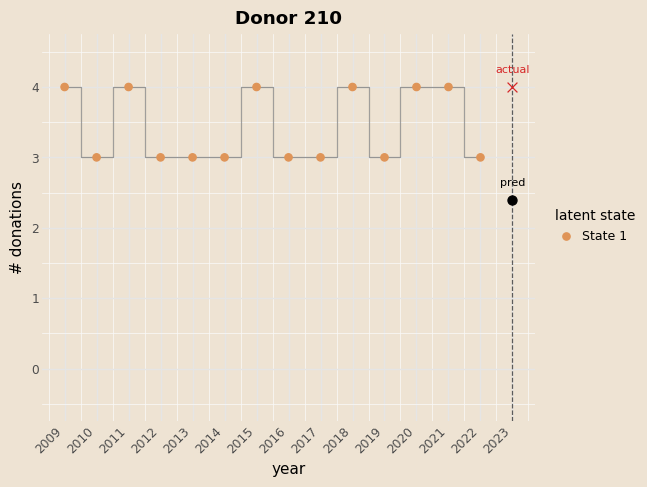

In [ ]:
# --- 1) Parametri modello e normalizzazione ---
W_A     = pyro.param("W_A").detach().cpu().numpy()        # (K,K,C_A)
beta_em = pyro.param("beta_em").detach().cpu().numpy()    # (K, C_em)
C_A  = W_A.shape[2]  # deve essere 8
C_em = beta_em.shape[1]  # deve essere 9
ages_mean = float(np.mean(ages))
ages_std  = float(np.std(ages) + 1e-6)

# --- 2) Donatore da predire ---
i = 210
years_hist = years_num[:-1].tolist()
year_next  = int(years_num[-1])
counts_hist = obs_torch[i, :len(years_hist)].detach().cpu().numpy().tolist()

birth_year = int(data["birth_year"][i])
gender     = data["gender"][i]

# --- 3) Builder per covariate compatibili con il training ---

def xA_builder(years, birth_year, gcode):
    # 8 colonne: intercept + 6 age-bin dummies + covid
    T = len(years)
    intercept = np.ones((T,1), dtype=np.float32)
    ages_ind = np.digitize(np.array(years)-birth_year, age_bins, right=False)  # 1..7
    ages_ind = np.clip(ages_ind, 1, n_agebins)
    ages_onehot = np.eye(n_agebins)[ages_ind-1][:,1:]  # drop baseline
    covid = np.isin(years, [2020,2021,2022]).astype(float)[:,None]
    X = np.concatenate([intercept, ages_onehot, covid], axis=1)  # (T,8)
    return X.astype(np.float32)

def xem_builder(years, birth_year, gcode):
    # 9 colonne: intercept + gender + 7 age-bin dummies + covid
    T = len(years)
    intercept = np.ones((T,1), dtype=np.float32)
    gender_col = np.full((T,1), 1.0 if gender=="F" else 0.0, dtype=np.float32)
    ages_ind = np.digitize(np.array(years)-birth_year, age_bins, right=False)
    ages_ind = np.clip(ages_ind, 1, n_agebins)
    ages_onehot = np.eye(n_agebins)[ages_ind-1][:,1:]  # drop baseline
    covid = np.isin(years, [2020,2021,2022]).astype(float)[:,None]
    X = np.concatenate([intercept, gender_col, ages_onehot, covid], axis=1)  # (T,9)
    return X.astype(np.float32)

# --- 4) Predizione ---
pred = predict_donor(
    birth_year=birth_year,
    gender=gender,
    history_years=years_hist,
    history_counts=counts_hist,
    next_year=year_next,
    max_k=4,
    x_A_builder=xA_builder,
    x_em_builder=xem_builder
)

# --- 5) Viterbi path e plotting ---
T_hist = len(years_hist)
N = obs_torch.shape[0]
paths = np.zeros((N,T_hist), dtype=int)
paths[i,:] = np.asarray(pred["viterbi_states"], dtype=int)

y_true_next = int(obs_torch[i, T_hist].detach().cpu().item())
p = hmm_pl.plot_donor_gg(
    idx=i,
    obs_torch=obs_torch[:, :T_hist],
    paths=paths,
    years=years_hist,
    expected_next=pred["expected_next"],
    y_true_next=y_true_next,
    next_year=year_next,
    y_max=4
)
p


# Comparison with a GLM

## GLM Poisson in Pyro

Let's define a vanilla GLM to check the results versus our model. 
Even thought is a easy model and it could be defined manually, or with simpler libraries, we decided to define it via Pyro.

- $y \sim \mathrm{Poisson}(\mu)$
- $\log \mu = \beta_0 + \beta_1 \text{birth\_year\_norm} + \beta_2 \text{gender}$

In [ ]:
from pyro.infer import SVI, Trace_ELBO
from pyro.optim import Adam
# Poisson GLM with log link
def glm_poisson_model(X, y=None, param_name="glm_beta"):
    N, C = X.shape
    beta = pyro.param(param_name, torch.zeros(C + 1, device=X.device))  # intercept + C slopes
    log_mu = beta[0] + (X @ beta[1:].unsqueeze(-1)).squeeze(-1)         # (N,)
    mu = log_mu.exp()
    with pyro.plate("data", N):
        pyro.sample("obs", dist.Poisson(mu), obs=y)

def glm_poisson_guide(X, y=None, param_name="glm_beta"):
    # Mean-field guide is empty: we use point estimates via pyro.param in the model.
    pass

# Train
def fit_glm_poisson(X, y, steps=3000, lr=1e-2, param_name="glm_beta", verbose_every=500, save_path="glm_poisson_params.pt"):
    X = X.detach()
    y = y.detach().float()
    pyro.clear_param_store()
    svi = SVI(
        lambda X_, y_: glm_poisson_model(X_, y_, param_name),
        lambda X_, y_: glm_poisson_guide(X_, y_, param_name),
        Adam({"lr": lr}),
        loss=Trace_ELBO()
    )
    loss_hist = []
    for s in range(steps):
        loss = svi.step(X, y)
        if verbose_every and s % verbose_every == 0:
            print(f"step {s:4d}: loss={loss:.3f}")
        loss_hist.append(loss)
    pyro.get_param_store().save(save_path)
    return loss_hist

# Predict and metrics
@torch.no_grad()
def glm_poisson_predict(X, param_name="glm_beta", return_proba=True):
    X = X.detach()
    beta = pyro.param(param_name)
    log_mu = (X @ beta[1:].unsqueeze(-1)).squeeze(-1)
    mu = log_mu.exp()  # expected counts
    if return_proba:
        p_donate = 1.0 - torch.exp(-mu)  # P(Y>0 | mu)
        return mu, p_donate
    return mu

@torch.no_grad()
def glm_poisson_evaluate_hmmstyle(X, y, param_name="glm_beta", return_all=False):
    """
    Metrics aligned with the HMM printout:
      - pred mean
      - obs mean
      - MSE
      - Accuracy (round)

    If return_all=True, also returns MAE, RMSE, NLL, Brier(y>0).
    """
    X = X.detach()
    y_f = y.detach().float()
    mu = glm_poisson_predict(X, param_name, return_proba=False)  # (N,)

    # HMM-style metrics
    pred_mean = mu.mean().item()
    obs_mean  = y_f.mean().item()
    mse = torch.mean((mu - y_f) ** 2).item()
    acc_round = torch.mean((torch.round(mu) == y_f).float()).item()

    out = {
        "pred mean": pred_mean,
        "obs mean": obs_mean,
        "MSE": mse,
        "Accuracy (round)": acc_round,
    }

    if return_all:
        mae = torch.mean(torch.abs(mu - y_f)).item()
        rmse = torch.sqrt(torch.mean((mu - y_f) ** 2)).item()
        nll = -torch.mean(dist.Poisson(mu).log_prob(y_f)).item()
        brier = torch.mean(((1.0 - torch.exp(-mu)) - (y_f > 0).float()) ** 2).item()
        out.update({"MAE": mae, "\nRMSE": rmse, "\nNLL": nll, "\nBrier(y>0)": brier})

    return out

In [ ]:
# y_train: last-year counts, X_train: corresponding covariates
y_train = obs_train[:, -1].float()
X_train = cov_train

y_test = obs_test[:, -1].float()
X_test = cov_test

loss_hist = fit_glm_poisson(X_train, y_train, steps=100, lr=1e-1, verbose_every=10)

step    0: loss=11023.613
step   10: loss=10730.555
step   20: loss=10675.722
step   30: loss=10679.677
step   40: loss=10667.932
step   50: loss=10665.433
step   60: loss=10664.562
step   70: loss=10664.539
step   80: loss=10664.321
step   90: loss=10664.209


## Evaluation

Save and load the model

In [ ]:
pyro.get_param_store().load("glm_poisson_params.pt")
metrics_glm = glm_poisson_evaluate_hmmstyle(X_test, y_test)
print(f"GLM: pred mean={metrics_glm['pred mean']:.2f}  obs mean={metrics_glm['obs mean']:.2f}")
print(f"MSE: {metrics_glm['MSE']:.4f}")
print(f"Accuracy (round): {100*metrics_glm['Accuracy (round)']:.2f}%")

GLM: pred mean=0.96  obs mean=0.91
MSE: 1.0158
Accuracy (round): 28.23%


## Prediction with HMM

In [ ]:
EPS = 1e-30

def softmax_row(x):
    x = x - x.max(axis=-1, keepdims=True)
    e = np.exp(x)
    return e / e.sum(axis=-1, keepdims=True)

def hmm_forward_predict(
    obs_so_far, xpi, xA, A_base, W_pi, W_A, pi_base, beta_em, cov_emission,
    steps_ahead=1
):
    """
    Predicts E[y_{T+steps_ahead}] with covariate-driven transitions and GLM emissions.

    Parameters
    ----------
    obs_so_far : (N, T_obs) array or None
        Observed history (used only for its length; no filtering).
    xpi : (N, C_pi) float
        Initial-state covariates.
    xA : (N, T_total, C_A) float
        Transition covariates for all times (must cover prediction index).
    A_base : (K, K) float, rows simplex
        Base transition matrix.
    W_pi : (K, C_pi) float
        Initial-state slopes.
    W_A : (K, K, C_A) float
        Transition slopes (row-wise).
    pi_base : (K,) float, simplex
        Base initial state.
    beta_em : (K, 1 + C_em) float
        Emission GLM coefficients (intercept + slopes) per state.
    cov_emission : (N, T_total, C_em) float
        Emission covariates at each time.
    steps_ahead : int
        How many steps ahead from T_obs to predict (>=1).

    Returns
    -------
    y_expected : (N,) float
        Predicted expected donations at prediction time.
    state_dist : (N, K) float
        Belief on hidden state at prediction time (after propagation).
    """
    N = xpi.shape[0]
    K = beta_em.shape[0]
    T_obs = 0 if (obs_so_far is None) else int(obs_so_far.shape[1])

    # 1) Initial alpha via softmax(log π_base + xπ Wπ^T)
    logits_pi = np.log(pi_base + EPS)[None, :] + xpi @ W_pi.T            # (N,K)
    alpha = softmax_row(logits_pi)                                       # (N,K)

    # 2) Propagation for steps_ahead
    #    For each t in [T_obs, T_obs+steps_ahead-1] build Aprob(n) = softmax_row(log A_base + W_A ⋅ xA[n,t,:])
    logA0 = np.log(A_base + EPS)                                         # (K,K)
    for t in range(T_obs, T_obs + steps_ahead):
        x_t = xA[:, t, :]                                                # (N,C_A)
        # slope logits: tensordot over C_A → (N,K,K)
        slope = np.tensordot(x_t, W_A, axes=([1], [2]))                  # (N,K,K)
        logits = logA0[None, :, :] + slope                               # (N,K,K)
        Aprob = softmax_row(logits)                                      # (N,K,K) row-softmax over axis=-1
        alpha = np.einsum('nk,nkj->nj', alpha, Aprob)                    # (N,K)

    # 3) Emission at prediction time
    t_pred = T_obs + steps_ahead - 1
    x_em = cov_emission[:, t_pred, :]                                    # (N,C_em)
    B  = beta_em[:, 1:]                                                  # (K,C_em)
    eta = x_em @ B.T                                                # (N,K)
    lam = np.exp(eta)                                                    # (N,K)

    # Expected count under mixture
    y_expected = (alpha * lam).sum(axis=1)                               # (N,)

    return y_expected, alpha

In [ ]:
beta_em.shape
# cov_emission_test_np.shape

(928, 15, 9)

In [ ]:
# Carica parametri
#W_pi, W_A, pi_base, A_base, beta_em = load_hmm_params("hmm_params.pt")

# Converte tensori PyTorch -> NumPy
obs_test_np         = obs_test.detach().cpu().numpy()
xpi_test_np         = xpi_test.detach().cpu().numpy()
xA_test_np          = xA_test.detach().cpu().numpy()
cov_emission_test_np= cov_emission_test.detach().cpu().numpy()

# Predici y_T (one-step ahead) usando osservazioni fino a T-1
y_pred_hmm, state_prob = hmm_forward_predict(
    obs_so_far      = obs_test_np[:, :-1],     # up to T-1
    xpi             = xpi_test_np,
    xA              = xA_test_np,
    A_base          = A_base,
    W_pi            = W_pi,
    W_A             = W_A,
    pi_base         = pi_base,
    beta_em         = beta_em,
    cov_emission    = cov_emission_test_np,    # (N_test, T, C_em)
    steps_ahead     = 1
)

In [ ]:
y_test = obs_test_np[:, -1]
print(f"HMM(full): pred mean={y_pred_hmm.mean():.2f}  obs mean={y_test.mean():.2f}")
print(f"MSE: {np.mean((y_pred_hmm - y_test)**2):.4f}")
print(f"Accuracy (round): {100*np.mean(np.round(y_pred_hmm)==y_test):.2f}%")

HMM(full): pred mean=0.41  obs mean=0.91
MSE: 1.2934
Accuracy (round): 40.73%


In [ ]:
def _to_numpy1d(x):
    if isinstance(x, torch.Tensor):
        x = x.detach().cpu().numpy()
    return np.asarray(x, dtype=float).ravel()

def build_hmm_metrics(y_pred_hmm, y_test):
    y_pred = _to_numpy1d(y_pred_hmm)
    y_true = _to_numpy1d(y_test)
    return {
        "pred mean": float(np.mean(y_pred)),
        "obs mean":  float(np.mean(y_true)),
        "MSE":       float(np.mean((y_pred - y_true) ** 2)),
        "Accuracy (round)": float(np.mean(np.round(y_pred) == y_true)),
    }

def pct_rel_diff(a, b, eps=1e-12):
    return 100.0 * (a - b) / (abs(b) + eps)

def print_comparison_table(metrics_glm, metrics_hmm):
    print(f"{'Metric':<20} {'GLM':>14} {'HMM':>14} {'Abs diff':>14} {'Rel diff %':>12}")
    print("-" * 76)
    order = ["pred mean", "obs mean", "MSE", "Accuracy (round)"]
    for key in order:
        g = metrics_glm[key]
        h = metrics_hmm[key]
        if key == "Accuracy (round)":
            g_disp = 100.0 * g
            h_disp = 100.0 * h
            abs_disp = 100.0 * (g - h)          # punti percentuali
            rel_pct = pct_rel_diff(g, h)
            print(f"{key:<20} {g_disp:14.2f}% {h_disp:14.2f}% {abs_disp:14.2f}pp {rel_pct:11.2f}%")
        elif key == "MSE":
            abs_diff = g - h
            rel_pct = pct_rel_diff(g, h)
            print(f"{key:<20} {g:14.4f} {h:14.4f} {abs_diff:14.4f} {rel_pct:11.2f}%")
        else:
            abs_diff = g - h
            rel_pct = pct_rel_diff(g, h)
            print(f"{key:<20} {g:14.2f} {h:14.2f} {abs_diff:14.2f} {rel_pct:11.2f}%")

In [ ]:
metrics_hmm = build_hmm_metrics(y_pred_hmm, y_test)

print_comparison_table(metrics_glm, metrics_hmm)

Metric                          GLM            HMM       Abs diff   Rel diff %
----------------------------------------------------------------------------
pred mean                      0.96           0.41           0.55      135.46%
obs mean                       0.91           0.91           0.00        0.00%
MSE                          1.0158         1.2934        -0.2777      -21.47%
Accuracy (round)              28.23%          40.73%         -12.50pp      -30.69%


# Number of latent states

In [ ]:
import hmm_glm_prediction 

In [ ]:
# functioon for building model and guide with covariates and K states 
def make_hmm_model_and_guide_cov(K):
    @config_enumerate
    def model(obs, x_pi, x_A, x_em):
        # forza obs a torch.Tensor
        obs = torch.as_tensor(obs)
        N, T = obs.shape
        C_pi = x_pi.shape[1]
        C_A  = x_A.shape[2]
        C_em = x_em.shape[2]

        # Priors
        alpha_pi = 0.5 * torch.ones(K)        # <1 → più “spiky”
        alpha_A  = torch.full((K, K), 0.5)
        alpha_A.fill_diagonal_(6.0)           # forte massa in diagonale
        
        pi_base = pyro.sample("pi_base", dist.Dirichlet(alpha_pi))             # [K]
        A_base  = pyro.sample("A_base",  dist.Dirichlet(alpha_A).to_event(1))  # [K,K]
        
        log_pi_base = pi_base.log()
        log_A_base  = A_base.log()

        # Parametri globali
        W_pi  = pyro.param("W_pi", 0.01 * torch.randn(K, C_pi))
        W_A   = pyro.param("W_A",  0.01 * torch.randn(K, K, C_A))
        beta_em = pyro.param("beta_em", 0.01 * torch.randn(K, C_em + 1))
        
        with pyro.plate("seqs", N):
            # stato iniziale
            logits0 = log_pi_base + (x_pi @ W_pi.T)
            z_prev = pyro.sample("z_0", dist.Categorical(logits=logits0),
                                infer={"enumerate": "parallel"})
            
            log_mu_0 = beta_em[z_prev, 0] + (x_em[:, 0, :] * beta_em[z_prev, 1:]).sum(-1)
            pyro.sample("y_0", dist.Poisson(log_mu_0.exp()), obs=obs[:, 0])

            # transizioni
            for t in range(1, T):
                x_t = x_A[:, t, :]
                
                logitsT = (log_A_base[z_prev] + (W_A[z_prev] * x_t[:, None, :]).sum(-1))
                z_t = pyro.sample(f"z_{t}", dist.Categorical(logits=logitsT),
                                infer={"enumerate": "parallel"})
                
                log_mu_t = beta_em[z_t, 0] + (x_em[:, t, :] * beta_em[z_t, 1:]).sum(-1)
                pyro.sample(f"y_{t}", dist.Poisson(log_mu_t.exp()), obs=obs[:, t])
                
                z_prev = z_t
        
      
    def guide(obs, x_pi, x_A, x_em):
        # forza obs a torch.Tensor
        obs = torch.as_tensor(obs)
        # Parametri MAP per pi e A
        pi_q = pyro.param("pi_base_map",
                        torch.ones(K) / K,
                        constraint=dist.constraints.simplex)

        A_init = torch.eye(K) * (K - 1.) + 1.
        A_init = A_init / A_init.sum(-1, keepdim=True)
        A_q = pyro.param("A_base_map",
                        A_init,
                        constraint=dist.constraints.simplex)

        pyro.sample("pi_base", dist.Delta(pi_q).to_event(1))
        pyro.sample("A_base",  dist.Delta(A_q).to_event(2))

    
    #num_params = K * x_pi.shape[1] + K * K * x_A.shape[2] + K * (x_em.shape[2] + 1) + K + K*K


    return model, guide

# Reads the variational parameters from the ParamStore and returns point estimates.
@torch.no_grad()
def extract_posterior_point_estimates_cov():
    
    store = pyro.get_param_store()

    def softmax_row(v):
        e = np.exp(v - np.max(v, axis=-1, keepdims=True))
        return e / e.sum(axis=-1, keepdims=True)

    # 1) Extract learned parameters
    pi_base = pyro.param("pi_base_map").detach().cpu().numpy()      # (K,) simplex
    A_base  = pyro.param("A_base_map").detach().cpu().numpy()       # (K, K) rows on simplex
    W_pi    = pyro.param("W_pi").detach().cpu().numpy()             # (K, C_pi)
    W_A     = pyro.param("W_A").detach().cpu().numpy()              # (K, K, C_A)
    beta_em = pyro.param("beta_em").detach().cpu().numpy()          # (K, 1 + C_em) if intercept first


    # 2) Covariate means
    x_mean_pi = cov_init_torch.mean(dim=0).detach().cpu().numpy()        # (C_pi,)
    x_mean_A  = cov_tran_torch.mean(dim=(0, 1)).detach().cpu().numpy()   # (C_A,)
    x_mean_em = cov_emiss_torch.mean(dim=(0,1)).detach().cpu().numpy()   # (C_em,)


    # 3) Mean initial probs, transitions and rates under average covariates
    logits_pi = np.log(pi_base + 1e-30) + W_pi @ x_mean_pi
    pi_mean   = softmax_row(logits_pi[None, :]).ravel()

    K = pi_mean.shape[0]
    A_mean = np.zeros((K, K))
    for k in range(K):
        logits_row = np.log(A_base[k] + 1e-30) + (W_A[k] @ x_mean_A)
        A_mean[k] = softmax_row(logits_row[None, :]).ravel()
   
    rates_mean = np.zeros(K)
    for k in range(K):
        log_mu = beta_em[k, 0] + np.dot(x_mean_em, beta_em[k, 1:])
        rates_mean[k] = np.exp(log_mu)

    return pi_mean, A_mean, rates_mean

# Uses the learned parameters from the ParamStore to make predictions on test data, compute MSE and Accuracy, and display a plot."
def evaluate_hmm_glm_prediction(obs_test, xpi_test, xA_test, cov_emission_test):
    
    store = pyro.get_param_store()

    def softmax_row(v):
        e = np.exp(v - np.max(v, axis=-1, keepdims=True))
        return e / e.sum(axis=-1, keepdims=True)

    # 1) Extract learned parameters
    pi_base = pyro.param("pi_base_map").detach().cpu().numpy()      # (K,)
    A_base  = pyro.param("A_base_map").detach().cpu().numpy()       # (K, K)
    W_pi    = pyro.param("W_pi").detach().cpu().numpy()             # (K, C_pi)
    W_A     = pyro.param("W_A").detach().cpu().numpy()              # (K, K, C_A)
    beta_em = pyro.param("beta_em").detach().cpu().numpy()          # (K, 1 + C_em)

    # 2) Convert test data to NumPy
    obs_test_np          = obs_test.detach().cpu().numpy()
    xpi_test_np          = xpi_test.detach().cpu().numpy()
    xA_test_np           = xA_test.detach().cpu().numpy()
    cov_emission_test_np = cov_emission_test.detach().cpu().numpy()

    # 3) One-step ahead prediction
    y_pred_hmm, state_prob = hmm_forward_predict(
        obs_so_far=obs_test_np[:, :-1],
        xpi=xpi_test_np,
        xA=xA_test_np,
        A_base=A_base,
        W_pi=W_pi,
        W_A=W_A,
        pi_base=pi_base,
        beta_em=beta_em,
        cov_emission=cov_emission_test_np,
        steps_ahead=1
    )

    # 4) True values
    y_test = obs_test_np[:, -1]

    # 5) Compute metrics
    mse = np.mean((y_pred_hmm - y_test)**2)
    acc = 100*np.mean(np.round(y_pred_hmm) == y_test)

    print(f"HMM(full): pred mean={y_pred_hmm.mean():.2f}  obs mean={y_test.mean():.2f}")
    print(f"MSE: {mse:.4f}")

    return y_pred_hmm, y_test, mse, acc

def log_softmax_logits(logits, dim=-1):
    return logits - torch.logsumexp(logits, dim=dim, keepdim=True)

# Computes the forward algorithm log-likelihood for a covariate-dependent HMM with Poisson emissions using the parameters stored in the Pyro ParamStore.
@torch.no_grad()
def forward_loglik_cov(obs, x_pi, x_A, x_em):
    device = obs.device
    ps = pyro.get_param_store()
    pi_base = ps["pi_base_map"].to(device)
    A_base  = ps["A_base_map"].to(device)
    W_pi    = ps["W_pi"].to(device)
    W_A     = ps["W_A"].to(device)
    beta_em = ps["beta_em"].to(device)

    N, T = obs.shape
    K = pi_base.shape[0]
    B  = beta_em[:, 1:]
    log_mu = torch.einsum("ntc,kc->ntk", x_em.to(device), B)
    emis_log = dist.Poisson(rate=log_mu.exp()).log_prob(obs.unsqueeze(-1))  # (N,T,K)

    log_pi = log_softmax_logits(pi_base.log() + x_pi @ W_pi.T, dim=1)       # (N,K)
    log_alpha = log_pi + emis_log[:, 0]

    log_A0 = A_base.log()
    for t in range(1, T):
        x_t = x_A[:, t, :]
        logits = log_A0.unsqueeze(0) + (W_A.unsqueeze(0) * x_t[:, None, None, :]).sum(-1)
        log_A = log_softmax_logits(logits, dim=2)
        log_alpha = torch.logsumexp(log_alpha.unsqueeze(2) + log_A, dim=1) + emis_log[:, t]
    return torch.logsumexp(log_alpha, dim=1)  # (N,)

# Evaluate HMM-GLM models with different numbers of latent states, evaluates them using log-evidence and prediction accuracy
def train_and_evaluate_cov(obs_torch, x_pi, x_A, x_em, K_list, n_steps=500, lr=1e-5):

    log_evidences = []
    final_elbos = []        # salvo gli ELBO finali
    accuracies = []         # salvo le accuracy

    for K in K_list:
        print(f"\n=== Training HMM with K={K} states ===")
        
        # crea modello e guida
        model, guide = make_hmm_model_and_guide_cov(K)

        # resetta ParamStore
        pyro.clear_param_store()

        svi = SVI(model, guide,
                  Adam({"lr": lr}),
                  loss=TraceEnum_ELBO(max_plate_nesting=1))

        losses = []
        for step in range(n_steps):
            loss = svi.step(obs_torch, x_pi, x_A, x_em)
            losses.append(loss)
            if step % 50 == 0:
                print(f"K={K} | step {step:4d}  ELBO = {loss:,.0f}")
        
        # ELBO finale
        final_elbo_val = -losses[-1]
        final_elbos.append(final_elbo_val)

        # 🔹 calcolo metriche di prediction (inclusa accuracy)
        _, _, mse, acc = evaluate_hmm_glm_prediction(obs_torch, x_pi, x_A, x_em)
        accuracies.append(acc)

        # calcola log-likelihood / evidenza
        log_evidence_val = forward_loglik_cov(obs_torch, x_pi, x_A, x_em).sum()
        log_evidences.append(log_evidence_val)
        print(f"Log-evidence K={K}: {log_evidence_val:.2f}")
        print(f"Accuracy K={K}: {acc:.2f}%")

    # 🔹 Plot evidenze e ELBO
    plt.figure(figsize=(10,5))
    plt.plot(K_list, log_evidences, marker='o', label="Log-evidence")
    #plt.plot(K_list, final_elbos, marker='x', label="Final ELBO")
    plt.xlabel("Number of latent states K")
    plt.ylabel("Value")
    plt.title("Model comparison via log-evidence and ELBO")
    plt.legend()
    plt.grid(True)
    plt.show()

    # 🔹 Plot accuracy come istogramma
    plt.figure(figsize=(8,5))
    plt.bar([str(K) for K in K_list], accuracies, color="skyblue")
    plt.xlabel("Number of latent states K")
    plt.ylabel("Accuracy (%)")
    plt.title("Prediction Accuracy by Model (HMM-GLM)")
    plt.grid(axis="y", linestyle="--", alpha=0.7)

    # settaggio asse y
    y_min = 30
    y_max = max(accuracies) + 2  # così lasci un po’ di margine sopra
    plt.ylim(y_min, y_max)
    plt.yticks(np.arange(y_min, y_max+1, 2))  # tick ogni 2

    plt.show()
    return K_list, log_evidences, final_elbos, accuracies 


=== Training HMM with K=2 states ===
K=2 | step    0  ELBO = 178,247
K=2 | step   50  ELBO = 169,945
HMM(full): pred mean=0.92  obs mean=0.97
MSE: 1.0489
Log-evidence K=2: -171336.64
Accuracy K=2: 28.79%

=== Training HMM with K=3 states ===
K=3 | step    0  ELBO = 177,609
K=3 | step   50  ELBO = 169,796
HMM(full): pred mean=0.92  obs mean=0.97
MSE: 1.0486
Log-evidence K=3: -171138.09
Accuracy K=3: 28.79%

=== Training HMM with K=4 states ===
K=4 | step    0  ELBO = 177,814
K=4 | step   50  ELBO = 169,750
HMM(full): pred mean=0.92  obs mean=0.97
MSE: 1.0490
Log-evidence K=4: -171224.23
Accuracy K=4: 28.79%

=== Training HMM with K=5 states ===
K=5 | step    0  ELBO = 177,521
K=5 | step   50  ELBO = 169,707
HMM(full): pred mean=0.91  obs mean=0.97
MSE: 1.0493
Log-evidence K=5: -171060.36
Accuracy K=5: 28.79%

=== Training HMM with K=6 states ===
K=6 | step    0  ELBO = 177,520
K=6 | step   50  ELBO = 169,616
HMM(full): pred mean=0.92  obs mean=0.97
MSE: 1.0481
Log-evidence K=6: -171116

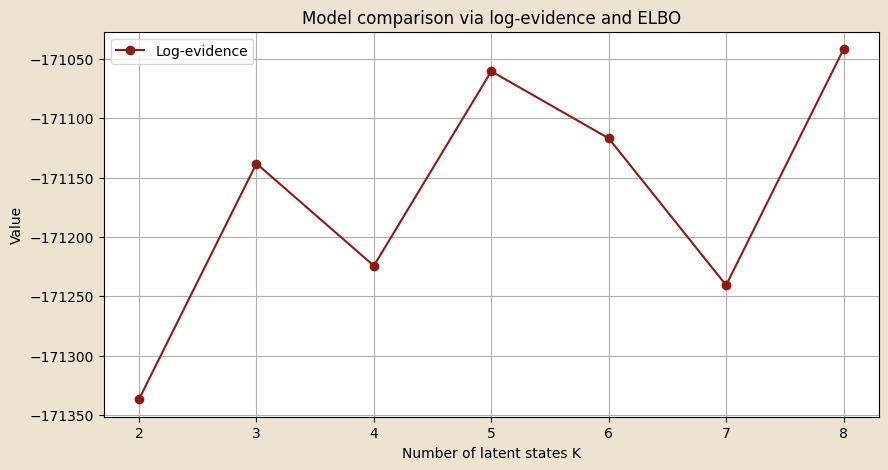

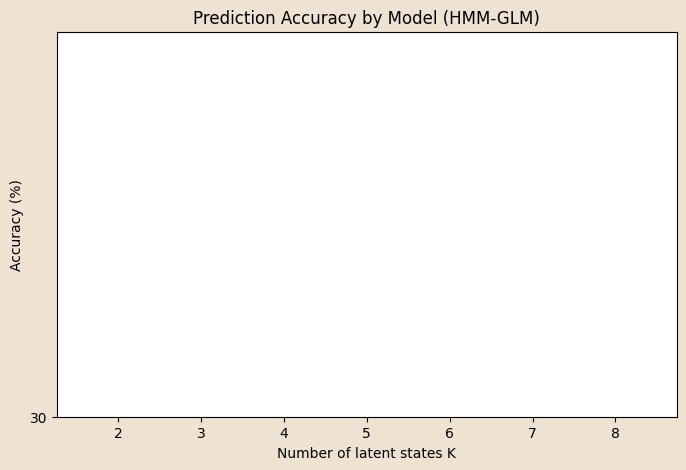

In [ ]:
K_list = range(2, 9)
K_list, log_evidences, final_elbos, accuracies = train_and_evaluate_cov(obs_torch, cov_init_torch, cov_tran_torch, cov_emiss_torch, K_list, n_steps=51, lr=2e-3)

In [ ]:
log_evidences

[tensor(-171336.6406),
 tensor(-171138.0938),
 tensor(-171224.2344),
 tensor(-171060.3594),
 tensor(-171116.8438),
 tensor(-171240.5781),
 tensor(-171041.7969)]

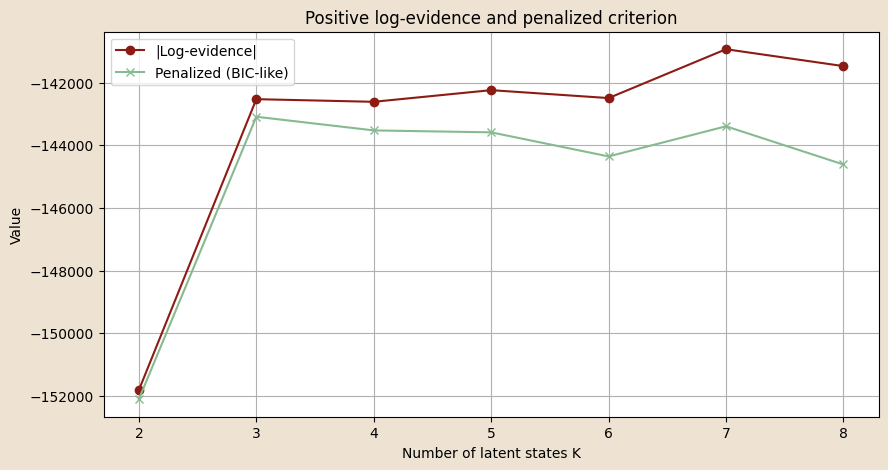

In [ ]:
C_pi = cov_init_torch.shape[1]
C_A  = cov_tran_torch.shape[2]
C_em = cov_emiss_torch.shape[2]


K_list = list(range(2, 9))
log_evidences = np.array([
   -151813.3281,
 -142526.,
 -142610.1406,
 -142238.3438,
 -142491.0469,
 -140931.5000,
 -141470.5000
])

# rendiamo valori positivi
#log_evidences_pos = np.abs(log_evidences)

# calcoliamo num_params per ciascun K
num_params_list = []
for K in K_list:
    num_params = K * C_pi + K * K * C_A + K * (C_em + 1) + K + K*K
    num_params_list.append(num_params)
num_params_list = np.array(num_params_list)

# numero di sequenze
N = 9236

# criterio penalizzato stile BIC
penalized = log_evidences - 0.5 * num_params_list * np.log(N)

# plot
plt.figure(figsize=(10, 5))
plt.plot(K_list, log_evidences, marker='o', label='|Log-evidence|')
plt.plot(K_list, penalized, marker='x', label='Penalized (BIC-like)')
plt.xlabel("Number of latent states K")
plt.ylabel("Value")
plt.title("Positive log-evidence and penalized criterion")
plt.grid(True)
plt.legend()
plt.show()